# **Importamos las dependencias**

In [1]:
# --- Librerías generales para manipulación y visualización de datos ---
import pandas as pd
# Configurar opciones de visualización de Pandas para mostrar más columnas y filas
pd.set_option("display.max_columns",30)
pd.set_option("display.max_rows",3000)

import numpy as np # Para operaciones numéricas y manejo de arrays
import os # Para manejar el Sistema Operativo

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns # Añadido: muy útil para visualizaciones estadísticas avanzadas
import cufflinks as cf
cf.go_offline() # Habilita el modo offline para cufflinks (gráficos interactivos en el notebook)
import plotly.express as px # Añadido: utilizado para crear gráficos interactivos, especialmente 3D


# --- Librerías para Machine Learning (Modelación No Supervisada) ---
# Modelos de Clustering
from sklearn.cluster import KMeans # Algoritmo de clustering K-Means
from sklearn.mixture import GaussianMixture # Algoritmo de clustering Gaussian Mixture Model (GMM)

# Transformaciones y Reducción de Dimensionalidad
from sklearn.preprocessing import MinMaxScaler, StandardScaler # Para escalar los datos (normalización/estandarización)
from sklearn.decomposition import PCA # Análisis de Componentes Principales (reducción de dimensionalidad)
from sklearn.manifold import MDS, TSNE # Otros métodos de reducción de dimensionalidad (MDS y t-SNE)

# **Carga de datos**

In [2]:
ruta_carpeta_csv = "/content/drive/MyDrive/Apuntes/Octavo semestre/Minería de datos/Programas/Práctica 4/Datos limpios"

all_dfs = []

print(f"Iniciando la lectura de archivos CSV desde: {ruta_carpeta_csv}")
for filename in os.listdir(ruta_carpeta_csv):
    if filename.endswith(".csv"):
        filepath = os.path.join(ruta_carpeta_csv, filename)
        try:
            df_temp = pd.read_csv(filepath)
            all_dfs.append(df_temp)
            print(f"  Cargado exitosamente: {filename} ({df_temp.shape[0]} filas, {df_temp.shape[1]} columnas)")
        except Exception as e:
            print(f"  ERROR: No se pudo cargar {filename}. Motivo: {e}")

# Concatenar todos los DataFrames en uno solo
if all_dfs:
    df = pd.concat(all_dfs, ignore_index=True)
    print(f"\n--- Lectura y concatenación finalizada ---")
    print(f"Todos los archivos CSV se han unido en un DataFrame final con {df.shape[0]} filas y {df.shape[1]} columnas.")
else:
    print("\n¡ATENCIÓN! No se encontraron archivos CSV en la ruta especificada o no se pudo cargar ninguno. El DataFrame final está vacío.")
    exit() # Detiene la ejecución si no hay DataFrame

print("\nPrimeras 5 filas del DataFrame combinado:")
print(df.head())

print("\nInformación general del DataFrame combinado (tipos de datos iniciales):")
df.info(memory_usage="deep")

print("\nValores únicos en la columna 'Genero_Usuario' (para revisión inicial):")
print(df['Genero_Usuario'].unique())


Iniciando la lectura de archivos CSV desde: /content/drive/MyDrive/Apuntes/Octavo semestre/Minería de datos/Programas/Práctica 4/Datos limpios
  Cargado exitosamente: 2010-04.csv (44984 filas, 4 columnas)
  Cargado exitosamente: 2010-05.csv (59814 filas, 4 columnas)
  Cargado exitosamente: 2010-06.csv (64704 filas, 4 columnas)
  Cargado exitosamente: 2010-07.csv (58767 filas, 4 columnas)
  Cargado exitosamente: 2010-08.csv (82329 filas, 4 columnas)
  Cargado exitosamente: 2010-02.csv (1057 filas, 4 columnas)
  Cargado exitosamente: 2010-03.csv (21024 filas, 4 columnas)
  Cargado exitosamente: 2010-09.csv (100164 filas, 4 columnas)
  Cargado exitosamente: 2010-10.csv (132294 filas, 4 columnas)
  Cargado exitosamente: 2010-11.csv (134082 filas, 4 columnas)
  Cargado exitosamente: 2010-12.csv (141860 filas, 4 columnas)
  Cargado exitosamente: 2011-01.csv (194027 filas, 4 columnas)
  Cargado exitosamente: 2011-02.csv (213473 filas, 4 columnas)
  Cargado exitosamente: 2011-04.csv (226501 fi

# **Limpieza de datos**

### **Tratamiento de nulos y casteo**

In [5]:
# Borramos los nulos
df = df.dropna()

df.isna().sum()/df.shape[0] * 100

,0
Genero_Usuario,0.0
Edad_Usuario,0.0
Fecha_Retiro,0.0
Fecha_Arribo,0.0


In [4]:
df['Edad_Usuario'] = df['Edad_Usuario'].astype('uint8')

mapeGen = {
    'M': 0,
    'F': 1,
}

df['Genero_Usuario'] = df['Genero_Usuario'].map(mapeGen)

In [ ]:
# Borramos los nulos
df = df.dropna()

df.isna().sum()/df.shape[0] * 100

In [6]:
df['Genero_Usuario'] = df['Genero_Usuario'].astype('uint8')
df['Fecha_Arribo'] = pd.to_datetime(df['Fecha_Arribo'])
df['Fecha_Retiro'] = pd.to_datetime(df['Fecha_Retiro'])

In [ ]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 118572121 entries, 0 to 119890347
Data columns (total 4 columns):
 #   Column          Dtype         
---  ------          -----         
 0   Genero_Usuario  uint8         
 1   Edad_Usuario    uint8         
 2   Fecha_Retiro    datetime64[ns]
 3   Fecha_Arribo    datetime64[ns]
dtypes: datetime64[ns](2), uint8(2)
memory usage: 2.9 GB


### **Tratamientos de nulos**

In [7]:
var_continuas = ['Edad_Usuario']

print("--- Iniciando Tratamiento de Outliers para ---")
percentiles = {}

for var in var_continuas: # Este bucle ahora solo procesará 'Edad_Usuario'
    print(f"\nProcesando outliers para la columna: {var}")

    # Calcular percentiles 1 y 99
    perc1 = df[var].describe(percentiles=[0.01]).to_frame().loc['1%', var]
    perc99 = df[var].describe(percentiles=[0.99]).to_frame().loc['99%', var]

    izq = round(perc1, 3)
    der = round(perc99, 3)

    print(f"  Límite inferior (1er percentil para {var}): {izq}")
    print(f"  Límite superior (99no percentil para {var}): {der}")

    # Identificar y reemplazar outliers con NaN
    df[var] = df[var].mask((df[var] <= izq) | (df[var] >= der))

    # Contar cuántos valores se mantuvieron (no son outliers)
    num_non_outliers = df[var].count()
    num_outliers = df[var].isnull().sum()

    print(f"  Valores originales en {var} dentro del rango (no outliers): {num_non_outliers}")
    print(f"  Valores originales en {var} reemplazados por NaN (outliers detectados): {num_outliers}")

print(f"\n--- Tratamiento de Outliers Finalizado ---")
print(f"Forma del DataFrame después del tratamiento de outliers: {df.shape}")

# Mostrar las primeras filas para ver el efecto (puede que aparezcan NaNs en 'Edad_Usuario')
print("\nPrimeras 5 filas del DataFrame con outliers de 'Edad_Usuario' tratados:")
print(df.head())

# Mostrar el porcentaje de nulos por columna para confirmar los cambios en 'Edad_Usuario'
print("\nPorcentaje de valores nulos por columna después del tratamiento de outliers:")
print(df.isnull().sum() / len(df) * 100)

--- Iniciando Tratamiento de Outliers para ---

Procesando outliers para la columna: Edad_Usuario
  Límite inferior (1er percentil para Edad_Usuario): 19.0
  Límite superior (99no percentil para Edad_Usuario): 64.0
  Valores originales en Edad_Usuario dentro del rango (no outliers): 115680554
  Valores originales en Edad_Usuario reemplazados por NaN (outliers detectados): 2891567

--- Tratamiento de Outliers Finalizado ---
Forma del DataFrame después del tratamiento de outliers: (118572121, 4)

Primeras 5 filas del DataFrame con outliers de 'Edad_Usuario' tratados:
   Genero_Usuario  Edad_Usuario Fecha_Retiro Fecha_Arribo
0               0          49.0   2010-04-01   2010-04-01
1               0          26.0   2010-04-01   2010-04-01
2               0          45.0   2010-04-01   2010-04-01
3               0          49.0   2010-04-01   2010-04-01
4               1          30.0   2010-04-01   2010-04-01

Porcentaje de valores nulos por columna después del tratamiento de outliers:
Ge

In [8]:
df = df.dropna()
df.isna().sum()/df.shape[0] * 100

,0
Genero_Usuario,0.0
Edad_Usuario,0.0
Fecha_Retiro,0.0
Fecha_Arribo,0.0


In [ ]:
df.shape[0]

115680554

### **Extracción ded características**

In [9]:
print("--- Extracción de características numéricas a partir de fechas ---")

# Característica 1: Duración de la estancia/periodo en días
# Calcula la diferencia entre Fecha_Arribo y Fecha_Retiro y la convierte a número de días.
df['Duracion_Dias'] = (df['Fecha_Arribo'] - df['Fecha_Retiro']).dt.days

# Característica 2: Mes de la Fecha_Retiro
df['Mes_Retiro'] = df['Fecha_Retiro'].dt.month

# Característica 3: Día de la semana de la Fecha_Retiro (0=Lunes, 6=Domingo)
df['Dia_Semana_Retiro'] = df['Fecha_Retiro'].dt.dayofweek

# Característica 4: Año de la Fecha_Retiro (útil si tus datos abarcan varios años)
df['Anio_Retiro'] = df['Fecha_Retiro'].dt.year

df['Mes_Arribo'] = df['Fecha_Arribo'].dt.month
df['Dia_Semana_Arribo'] = df['Fecha_Arribo'].dt.dayofweek
df['Anio_Arribo'] = df['Fecha_Arribo'].dt.year
# df['Es_Fin_Semana_Retiro'] = df['Dia_Semana_Retiro'].isin([5, 6]).astype(int) # 1 si es fin de semana, 0 si no

print("\nNuevas características derivadas de las fechas creadas.")

# Mostrar las primeras filas con las nuevas columnas
print("\nPrimeras 5 filas del DataFrame con nuevas características de fecha:")
print(df.head())

# Mostrar la información del DataFrame para ver los tipos de datos de las nuevas columnas
print("\nInformación del DataFrame con nuevas características de fecha:")
df.info()

# Verificar si hay NaNs en las nuevas columnas (puede ocurrir si las fechas originales eran NaT)
print("\nValores nulos en las nuevas columnas de fecha:")
print(df[['Duracion_Dias', 'Mes_Retiro', 'Dia_Semana_Retiro', 'Anio_Retiro']].isnull().sum())

--- Extracción de características numéricas a partir de fechas ---

Nuevas características derivadas de las fechas creadas.

Primeras 5 filas del DataFrame con nuevas características de fecha:
   Genero_Usuario  Edad_Usuario Fecha_Retiro Fecha_Arribo  Duracion_Dias  \
0               0          49.0   2010-04-01   2010-04-01              0   
1               0          26.0   2010-04-01   2010-04-01              0   
2               0          45.0   2010-04-01   2010-04-01              0   
3               0          49.0   2010-04-01   2010-04-01              0   
4               1          30.0   2010-04-01   2010-04-01              0   

   Mes_Retiro  Dia_Semana_Retiro  Anio_Retiro  Mes_Arribo  Dia_Semana_Arribo  \
0           4                  3         2010           4                  3   
1           4                  3         2010           4                  3   
2           4                  3         2010           4                  3   
3           4                 

In [ ]:
df.isna().sum()/df.shape[0]

,0
Genero_Usuario,0.0
Edad_Usuario,0.0
Fecha_Retiro,0.0
Fecha_Arribo,0.0
Duracion_Dias,0.0
Mes_Retiro,0.0
Dia_Semana_Retiro,0.0
Anio_Retiro,0.0
Mes_Arribo,0.0
Dia_Semana_Arribo,0.0


### **Exploración**

<Axes: xlabel='Edad_Usuario', ylabel='Count'>

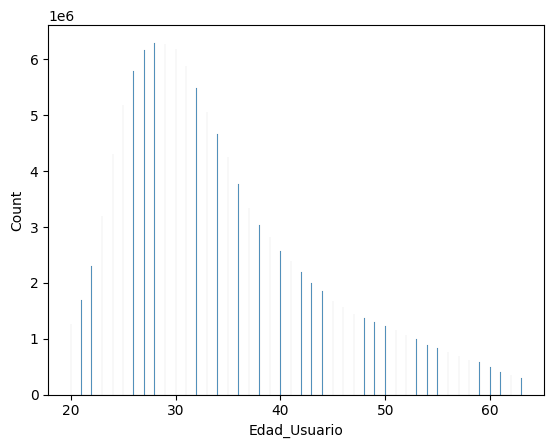

In [ ]:
sns.histplot(data=df[["Edad_Usuario"]], x='Edad_Usuario')

<Axes: xlabel='Genero_Usuario', ylabel='Count'>

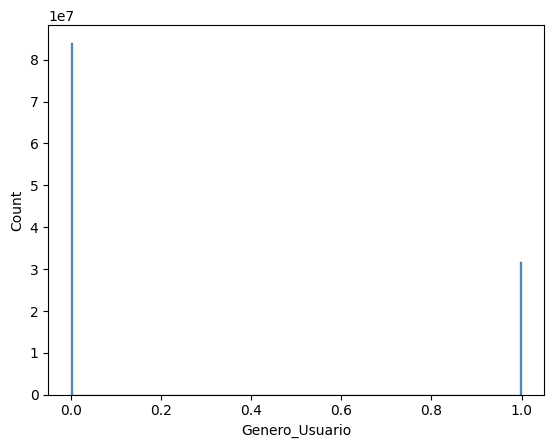

In [ ]:
sns.histplot(data=df[['Genero_Usuario']], x="Genero_Usuario")

### **Escalado**

In [11]:
cols_to_scale = ['Edad_Usuario']

# Crear una copia de la sección del DataFrame que se va a escalar
X_escalar = df[cols_to_scale].copy()

# Inicializar el MinMaxScaler
minmax_scaler = MinMaxScaler()

# Ajustar el scaler a los datos y transformarlos
Xs = pd.DataFrame(minmax_scaler.fit_transform(X_escalar), columns=cols_to_scale)

print("--- Escalado de datos con MinMaxScaler completado ---")
print(Xs.head())

--- Escalado de datos con MinMaxScaler completado ---
   Edad_Usuario
0      0.674419
1      0.139535
2      0.581395
3      0.674419
4      0.232558


In [12]:
cols_para_clustering = [
    'Genero_Usuario',
    'Edad_Usuario',
    'Duracion_Dias',
    'Mes_Retiro',
    'Dia_Semana_Retiro',
    'Anio_Retiro'
]


print("Verificando NaNs en columnas para clustering antes de escalar:")
print(df[cols_para_clustering].isnull().sum())


X_clustering = df[cols_para_clustering].copy()

# Inicializar el MinMaxScaler
minmax_scaler_final = MinMaxScaler()

# Ajustar el scaler a los datos y transformarlos
X_escalado_final = pd.DataFrame(minmax_scaler_final.fit_transform(X_clustering), columns=cols_para_clustering)

print("\n--- Escalado FINAL de todas las características numéricas para clustering completado ---")
print("\nPrimeras 5 filas de las características escaladas (X_escalado_final):")
print(X_escalado_final.head())

Verificando NaNs en columnas para clustering antes de escalar:
Genero_Usuario       0
Edad_Usuario         0
Duracion_Dias        0
Mes_Retiro           0
Dia_Semana_Retiro    0
Anio_Retiro          0
dtype: int64

--- Escalado FINAL de todas las características numéricas para clustering completado ---

Primeras 5 filas de las características escaladas (X_escalado_final):
   Genero_Usuario  Edad_Usuario  Duracion_Dias  Mes_Retiro  Dia_Semana_Retiro  \
0             0.0      0.674419            0.0    0.272727                0.5   
1             0.0      0.139535            0.0    0.272727                0.5   
2             0.0      0.581395            0.0    0.272727                0.5   
3             0.0      0.674419            0.0    0.272727                0.5   
4             1.0      0.232558            0.0    0.272727                0.5   

   Anio_Retiro  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          0.0  


# **Modelado**

### **KMeans**

--- Calculando la inercia para el Método del Codo ---
  Calculada inercia para k=1
  Calculada inercia para k=2
  Calculada inercia para k=3
  Calculada inercia para k=4


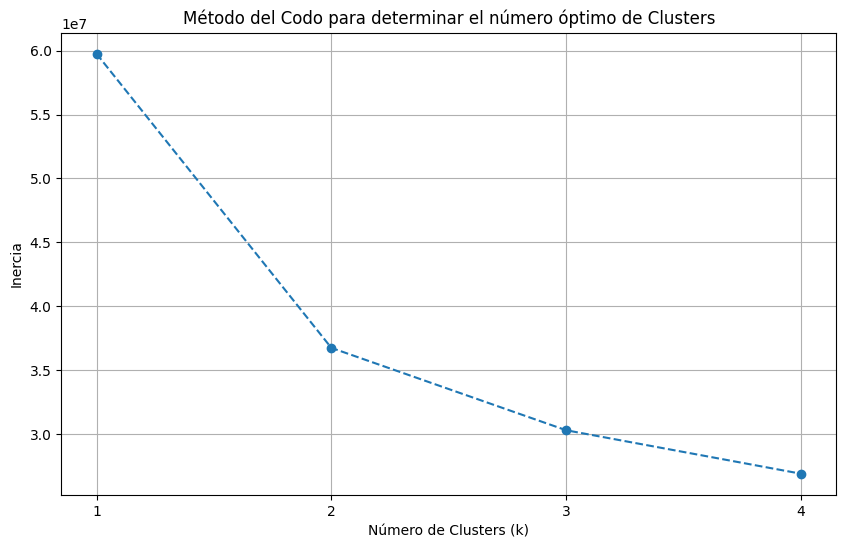


Valores de Inercia para cada número de clusters:
k=1: 59764950.77
k=2: 36738555.57
k=3: 30290167.86
k=4: 26887312.05


In [13]:
# Lista para almacenar la inercia para cada número de clusters
lst_in = []

range_n_clusters = range(1, 5)

print("--- Calculando la inercia para el Método del Codo ---")

for k in range_n_clusters:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)

    km.fit(X_escalado_final)

    lst_in.append(km.inertia_)
    print(f"  Calculada inercia para k={k}")

# Grafica
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, lst_in, marker='o', linestyle='--')
plt.title('Método del Codo para determinar el número óptimo de Clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.xticks(range_n_clusters)
plt.show()

print("\nValores de Inercia para cada número de clusters:")
for k_val, inertia_val in zip(range_n_clusters, lst_in):
    print(f"k={k_val}: {inertia_val:.2f}")

In [15]:
n_clusters = 4
print(f"\nNúmero de clusters elegido: k={n_clusters}")

# --- 1. Aplicación del Algoritmo de Clustering (KMeans) ---
print(f"\n--- Aplicando KMeans con k={n_clusters} clusters ---")

km_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
km_model.fit(X_escalado_final)

# Asignar cada punto a un cluster
cluster_assignments_numpy = km_model.predict(X_escalado_final)

# Añadir la columna de asignación de cluster al DataFrame original (df)
# Aseguramos que el índice coincida, usando df.index para Series
df['cluster_kmeans'] = pd.Series(cluster_assignments_numpy, index=df.index).astype('uint8')

print(f"\n--- Clustering con KMeans (k={n_clusters}) completado ---")
print("\nPrimeras 5 filas del DataFrame con la asignación de cluster (df con 'cluster_kmeans'):")
print(df.head())

print("\nDistribución de puntos por cada cluster (conteo - KMeans):")
print(df["cluster_kmeans"].value_counts().sort_index())

print("\nPorcentaje de puntos por cada cluster (KMeans):")
print(df["cluster_kmeans"].value_counts(normalize=True).sort_index())


# --- 2. Perfilamiento de Clusters ---
print("\n--- Iniciando Perfilamiento de Clusters (KMeans) ---")



Número de clusters elegido: k=4

--- Aplicando KMeans con k=4 clusters ---

--- Clustering con KMeans (k=4) completado ---

Primeras 5 filas del DataFrame con la asignación de cluster (df con 'cluster_kmeans'):
   Genero_Usuario  Edad_Usuario Fecha_Retiro Fecha_Arribo  Duracion_Dias  \
0               0          49.0   2010-04-01   2010-04-01              0   
1               0          26.0   2010-04-01   2010-04-01              0   
2               0          45.0   2010-04-01   2010-04-01              0   
3               0          49.0   2010-04-01   2010-04-01              0   
4               1          30.0   2010-04-01   2010-04-01              0   

   Mes_Retiro  Dia_Semana_Retiro  Anio_Retiro  Mes_Arribo  Dia_Semana_Arribo  \
0           4                  3         2010           4                  3   
1           4                  3         2010           4                  3   
2           4                  3         2010           4                  3   
3          

In [18]:
# Columnas a perfilar: todas las numéricas que usamos para clustering
profiling_cols = [
    'Genero_Usuario',
    'Edad_Usuario',
    'Duracion_Dias',
    'Mes_Retiro',
    'Dia_Semana_Retiro',
    'Anio_Retiro',
    'Mes_Arribo',
    'Dia_Semana_Arribo',
    'Anio_Arribo'
]

# Calcular la media de cada característica por cluster
print("\n--- Estadísticas descriptivas de cada característica por Cluster (Medias - KMeans) ---")
cluster_profiles_mean_kmeans = df.groupby("cluster_kmeans")[profiling_cols].mean()
print(cluster_profiles_mean_kmeans)





--- Estadísticas descriptivas de cada característica por Cluster (Medias - KMeans) ---
                Genero_Usuario  Edad_Usuario  Duracion_Dias  Mes_Retiro  \
cluster_kmeans                                                            
0                          0.0     34.953484       0.004839    9.791546   
1                          1.0     32.816306       0.005827    6.341844   
2                          0.0     34.716833       0.010352    5.637898   
3                          0.0     34.962421       0.007360    3.397248   

                Dia_Semana_Retiro  Anio_Retiro  Mes_Arribo  Dia_Semana_Arribo  \
cluster_kmeans                                                                  
0                        1.867534  2017.882080    9.791567           1.869984   
1                        2.650812  2019.215584    6.341989           2.651630   
2                        4.609452  2019.651288    5.638202           4.607351   
3                        1.376965  2019.556194    3.3975

In [19]:
# Calculamos la mediana para ver la tendencia central en datos sesgados
print("\n--- Estadísticas descriptivas de cada característica por Cluster (Medianas - KMeans) ---")
cluster_profiles_median_kmeans = df.groupby("cluster_kmeans")[profiling_cols].median()
print(cluster_profiles_median_kmeans)


--- Estadísticas descriptivas de cada característica por Cluster (Medianas - KMeans) ---
                Genero_Usuario  Edad_Usuario  Duracion_Dias  Mes_Retiro  \
cluster_kmeans                                                            
0                          0.0          33.0            0.0        10.0   
1                          1.0          31.0            0.0         6.0   
2                          0.0          33.0            0.0         5.0   
3                          0.0          33.0            0.0         3.0   

                Dia_Semana_Retiro  Anio_Retiro  Mes_Arribo  Dia_Semana_Arribo  \
cluster_kmeans                                                                  
0                             2.0       2017.0        10.0                2.0   
1                             3.0       2019.0         6.0                3.0   
2                             4.0       2020.0         5.0                4.0   
3                             1.0       2019.0        